# Imports

In [1]:
!pip install -q statsforecast mlforecast neuralforecast lightgbm pyarrow utilsforecast timecopilot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from functools import partial

# StatsForecast ---
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    AutoETS,
    AutoARIMA,
)

#  UtilsForecast
from utilsforecast.losses import mae, rmse, mape, mase, bias
from utilsforecast.evaluation import evaluate


# ML model
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
import lightgbm as lgb

# Foundation model
from timecopilot.forecaster import TimeCopilotForecaster
from timecopilot.models.foundation.chronos import Chronos

# Output folder
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)


df = pd.read_parquet("sample_hotels-1.parquet")


print(df.head())
print(df.columns)
print(df.shape)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 25.1.0 requires cryptography<46,>=41.0.5, but you have cryptography 48.0.0 which is incompatible.
tensorflow 2.15.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow 2.15.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 which is incompatible.
tensorflow 2.15.1 requires tensorboard<2.16,>=2.15, but you have tensorboard 2.20.0 which is incompatible.
databricks-sqlalchemy 1.0.5 requires pyarrow<17,>=14.0.1, but you have pyarrow 23.0.1 which is incompatible.
deepnote-toolkit 2.2.1 requires cryptography<47,>=46.0.5, but you have cryptography 48.0.0 which is incompatible.
deepnote-toolkit 2.2.1 requires dill<=0.4,>=0.3.8; python_version <= "3.12", but you have dill 0.4.1 which is incompatible.
deepn

# Cleaning

In [3]:
!pip install -q holidays
import holidays

us_holidays = holidays.US()

df = df.assign(
    ds=lambda x: pd.to_datetime(x["ds"]),
    unique_id=lambda x: x["unique_id"].astype(str),
    y=lambda x: pd.to_numeric(x["y"], errors="coerce"),
    holiday_flag=lambda x: x["holiday_flag"].astype(bool),
    hotel_type=lambda x: x["hotel_type"].astype("category"),
    location_type=lambda x: x["location_type"].astype("category"),
    holiday_name=lambda x: (
        x["ds"]
        .dt.date
        .apply(lambda y: us_holidays.get(y))
        .fillna("None")
        .astype("category")
    ),
    day_of_week=lambda x: x["ds"].dt.day_name().astype("category")
)

df = df.dropna(subset=["ds", "unique_id", "y"])
df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

print(df.head())
print(df.shape)
print(df["unique_id"].nunique())
print(df.dtypes)


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
  unique_id         ds  holiday_flag target_day target_month  target_year  \
0   hotel_0 2022-01-01          True        Sat          Jan         2022   
1   hotel_0 2022-01-02          True        Sun          Jan         2022   
2   hotel_0 2022-01-03          True        Mon          Jan         2022   
3   hotel_0 2022-01-04          True        Tue          Jan         2022   
4   hotel_0 2022-01-05          True        Wed          Jan         2022   

  location_type              hotel_type         y     otb_1  ...    otb_53  \
0   NonSuburban  Resorts & Destinations  0.975309  0.679012  ...  0.197531   
1   NonSuburban  Resorts & Destinations  0.493827  0.308642  ...  0.074074   
2   NonSuburban  Resorts & Destinations  0.456790  0.358025  ...  0.024691   
3   NonSuburban  Resorts & Destinations  0.592593  0.419753  ...  0.074074   
4   NonSuburban  Resorts & Destinati

In [5]:
print(sorted(df["unique_id"].unique()))
hotel_summary = df.groupby("unique_id").agg(
    first_date=("ds", "min"),
    last_date=("ds", "max"),
    n_observations=("ds", "count")
).reset_index()

print(hotel_summary)

['hotel_0', 'hotel_105', 'hotel_112', 'hotel_126', 'hotel_133', 'hotel_14', 'hotel_21', 'hotel_28', 'hotel_35', 'hotel_42', 'hotel_49', 'hotel_56', 'hotel_63', 'hotel_7', 'hotel_70', 'hotel_77', 'hotel_84', 'hotel_91', 'hotel_98']
    unique_id first_date  last_date  n_observations
0     hotel_0 2022-01-01 2023-06-30             546
1   hotel_105 2022-01-01 2023-06-30             546
2   hotel_112 2022-01-01 2023-06-30             546
3   hotel_126 2022-01-01 2023-06-30             546
4   hotel_133 2022-01-01 2023-06-30             546
5    hotel_14 2022-01-01 2023-06-30             546
6    hotel_21 2022-01-01 2023-06-30             546
7    hotel_28 2022-01-01 2023-06-30             546
8    hotel_35 2022-01-01 2023-06-30             546
9    hotel_42 2022-01-01 2023-06-30             546
10   hotel_49 2022-01-01 2023-06-30             546
11   hotel_56 2022-01-01 2023-06-30             546
12   hotel_63 2022-01-01 2023-06-30             546
13    hotel_7 2022-01-01 2023-06-30      

# Cleaning \+ Visualization

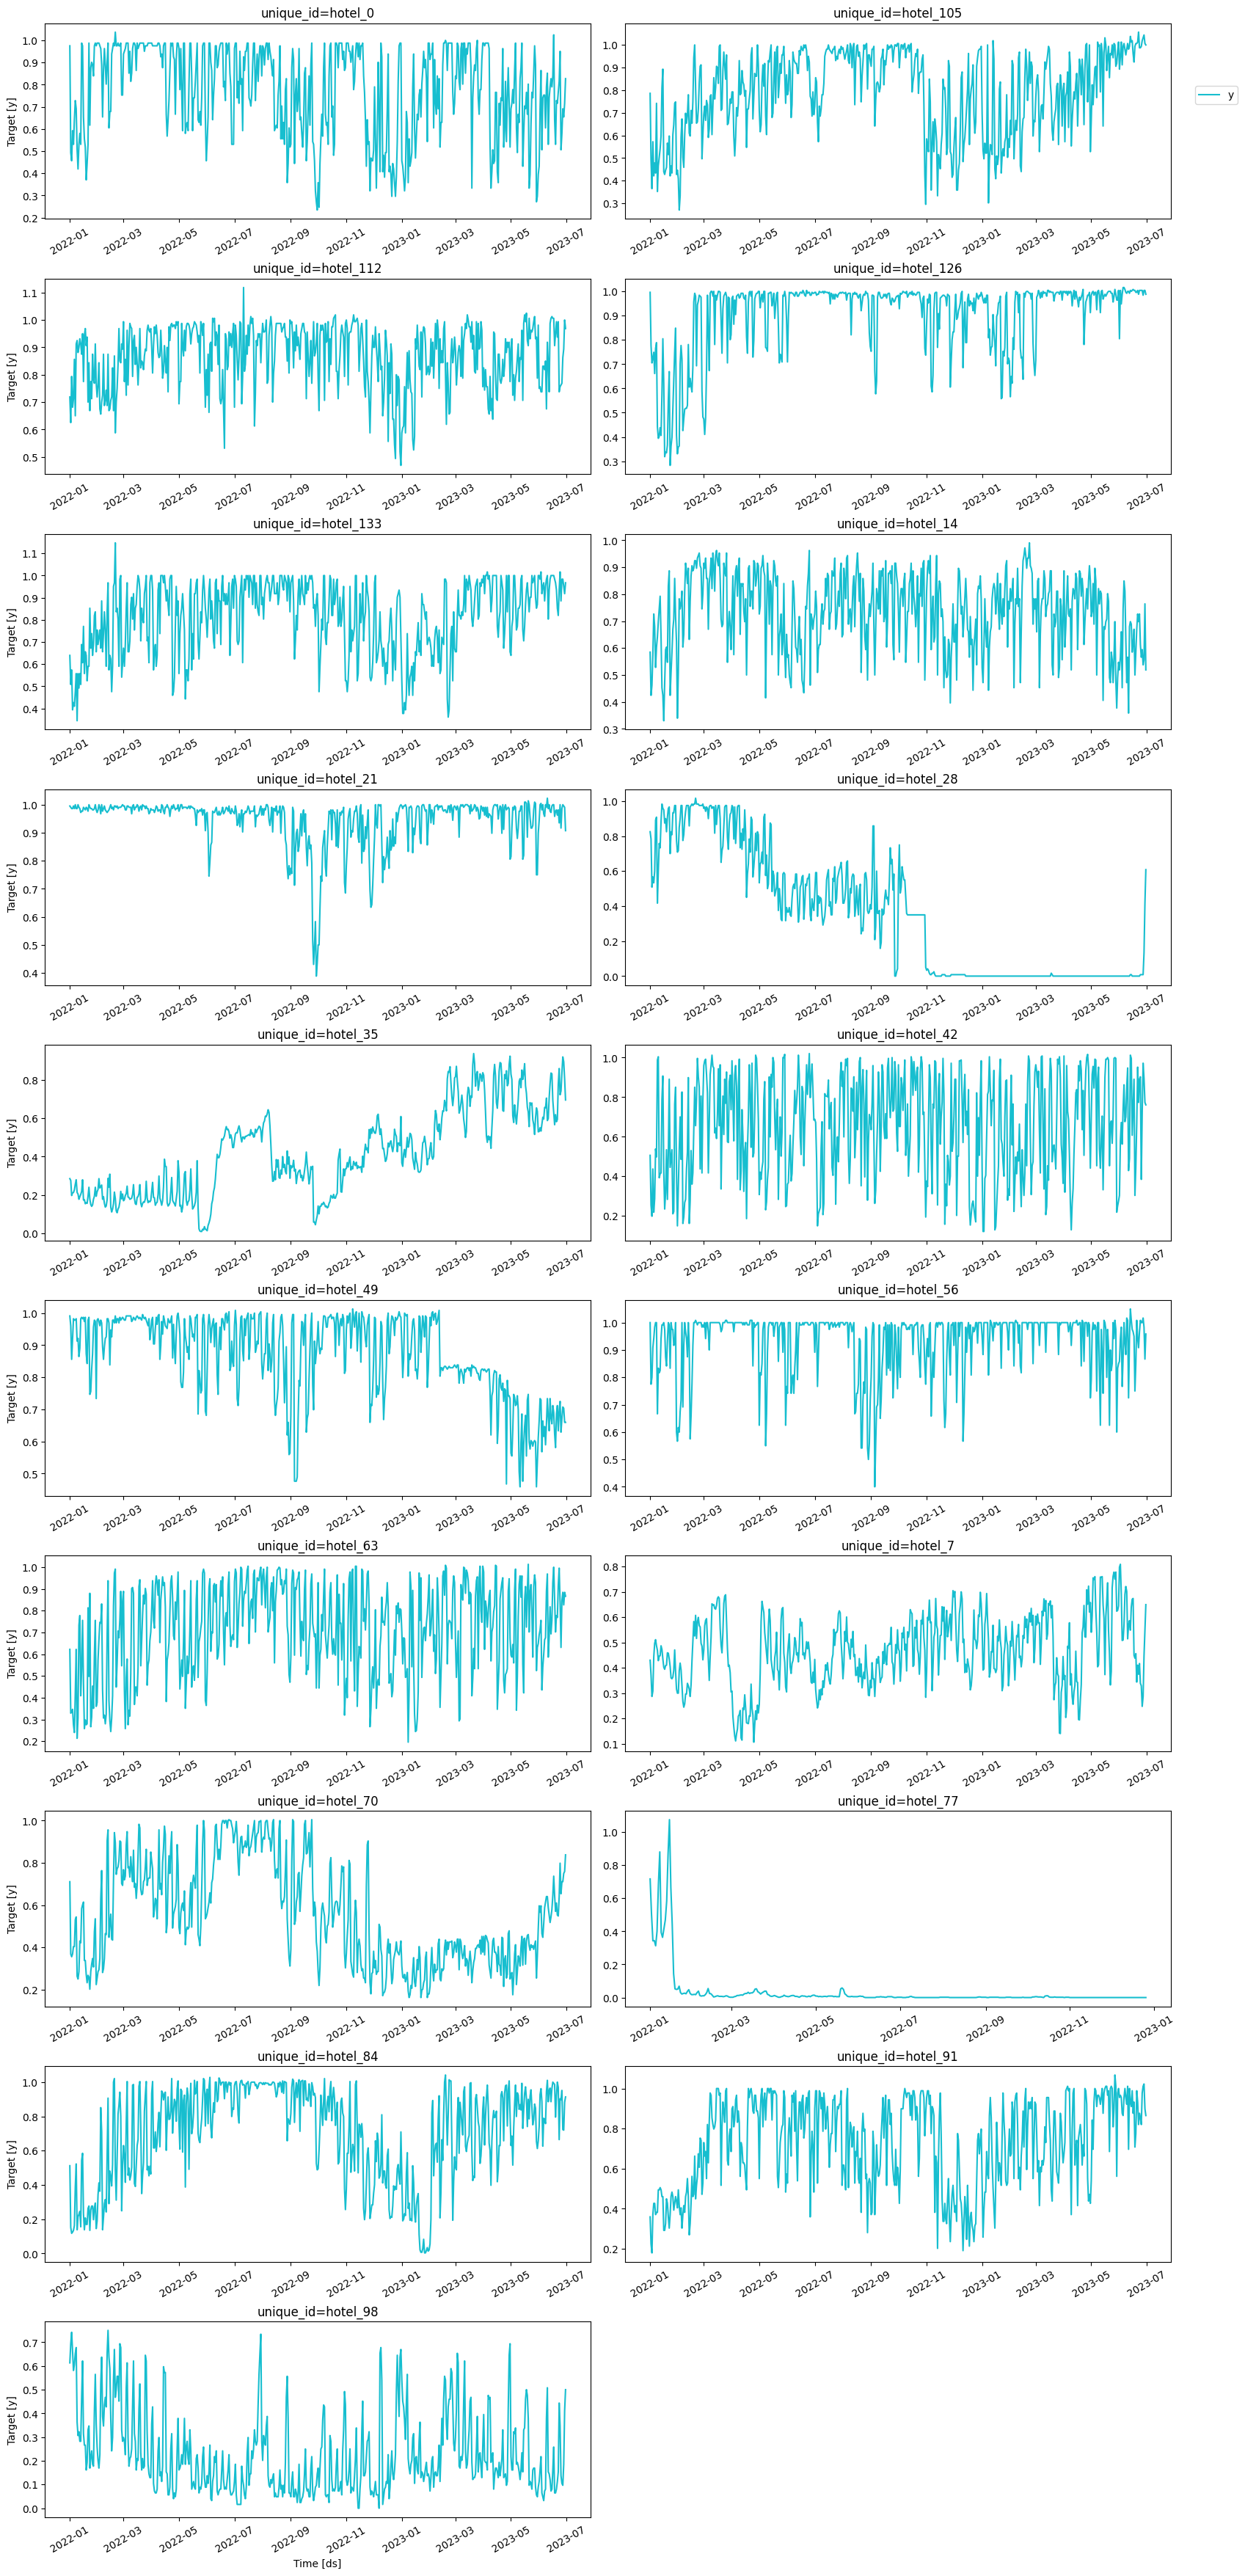

In [7]:
from utilsforecast.plotting import plot_series

plot_series(df, max_ids=19)

# Removing 77 and 28

In [9]:
# Removed hotel 77 and hotel 28 due to them being insignificant
df = df[~df['unique_id'].isin(['hotel_77', 'hotel_28'])].reset_index(drop=True)

print(sorted(df['unique_id'].unique()))

hotel_summary = df.groupby('unique_id').agg(
    first_date=('ds', 'min'),
    last_date=('ds', 'max'),
    n_observations=('ds', 'count')
).reset_index()

print(hotel_summary)

['hotel_0', 'hotel_105', 'hotel_112', 'hotel_126', 'hotel_133', 'hotel_14', 'hotel_21', 'hotel_35', 'hotel_42', 'hotel_49', 'hotel_56', 'hotel_63', 'hotel_7', 'hotel_70', 'hotel_84', 'hotel_91', 'hotel_98']
    unique_id first_date  last_date  n_observations
0     hotel_0 2022-01-01 2023-06-30             546
1   hotel_105 2022-01-01 2023-06-30             546
2   hotel_112 2022-01-01 2023-06-30             546
3   hotel_126 2022-01-01 2023-06-30             546
4   hotel_133 2022-01-01 2023-06-30             546
5    hotel_14 2022-01-01 2023-06-30             546
6    hotel_21 2022-01-01 2023-06-30             546
7    hotel_35 2022-01-01 2023-06-30             546
8    hotel_42 2022-01-01 2023-06-30             546
9    hotel_49 2022-01-01 2023-06-30             546
10   hotel_56 2022-01-01 2023-06-30             546
11   hotel_63 2022-01-01 2023-06-30             546
12    hotel_7 2022-01-01 2023-06-30             546
13   hotel_70 2022-01-01 2023-06-30             546
14   hotel_84

# Creating Training and Importing Models

In [54]:
baseline_models_no_pred = [
    Naive(alias='Naive'),

    SeasonalNaive(season_length=7, alias = 'LastWeek'),
    SeasonalNaive(season_length=30, alias = 'LastMonth'),
    SeasonalNaive(season_length=365, alias = 'LastYear'),

    AutoETS(season_length=7, alias = 'AutoETS'),
    AutoARIMA(season_length=7, alias = 'AutoARIMA'),

  # MSTL(season_length = [7, 30], alias='MSTL'),
]

sf_no_pred = StatsForecast( models= baseline_models_no_pred, freq = 'D' )

cv_no_pred = sf_no_pred.cross_validation(
    h = 28, 
    df = df[['unique_id', 'ds', 'y']], 
    n_windows = 5, 
    step_size = 28
)

# Cross Validation

In [56]:
sf_no_pred = StatsForecast(
    models=baseline_models_no_pred,
    freq="D"
)

cv_no_pred = sf_no_pred.cross_validation(
    h=28,
    df=df[['unique_id', 'ds', 'y']],
    n_windows=5,
    step_size=28
)

cv_no_pred.head()

,unique_id,ds,cutoff,y,Naive,LastWeek,LastMonth,LastYear,AutoETS,AutoARIMA
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.493827,0.901235,0.798058,0.777053
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.790123,0.987654,0.592257,0.612408
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.938272,0.604938,0.611757,0.798756
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.604938,0.679012,0.625062,0.785560
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.469136,0.679012,0.616607,0.793339


# Evaluate

In [60]:
model_names = ['Naive', 'LastWeek', 'LastMonth', 'LastYear', 'AutoETS', 'AutoARIMA']

eval_no_pred = evaluate(
    cv_no_pred,
    metrics=[bias, rmse, mae, mape],
    models=model_names,
)

eval_statsforecast = (
    eval_no_pred
    .drop(columns=['cutoff'])
    .groupby(['unique_id', 'metric'])
    .mean()
    .reset_index()
)

eval_statsforecast.to_csv("sf_eval.csv", index=False)

display(eval_statsforecast)

,unique_id,metric,Naive,LastWeek,LastMonth,LastYear,AutoETS,AutoARIMA
0,hotel_0,bias,0.082011,0.029806,0.011905,0.118430,-0.007384,0.052847
1,hotel_0,mae,0.194709,0.214286,0.228836,0.162169,0.184314,0.164152
2,hotel_0,mape,0.341090,0.354191,0.370882,0.300784,0.297296,0.283008
3,hotel_0,rmse,0.238226,0.252785,0.271480,0.222884,0.216098,0.195586
4,hotel_105,bias,0.053190,-0.073854,-0.075651,-0.045553,-0.062427,-0.060943
...,...,...,...,...,...,...,...,...
63,hotel_91,rmse,0.203626,0.242046,0.255833,0.242977,0.174002,0.176987
64,hotel_98,bias,0.063018,-0.008641,-0.001152,-0.008871,-0.017763,-0.022919
65,hotel_98,mae,0.184677,0.147696,0.188364,0.143433,0.154391,0.113024
66,hotel_98,mape,1.085660,0.698302,1.102256,0.652018,0.741485,0.541061


# LightGBM

Include predictors such as hotel type and hotel location

In [19]:

from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

ml_models = {
    'LightGBM': LGBMRegressor(verbose=-1)
}

ml = MLForecast(
    models=ml_models,
    freq='D',
    lags=[28, 35, 42, 49, 56, 60, 90],       
    lag_transforms={
        28: [
            RollingMean(window_size=7),
            RollingMean(window_size=14),
        ]
    },
    date_features=['year', 'month']
)

cross_ml = ml.cross_validation(
    df=df[['unique_id', 'ds', 'y', 'hotel_type', 'location_type']],
    n_windows=5,
    h=28,
    step_size=28,
    static_features=[]
)

eval_ml = evaluate(
    df=cross_ml,
    metrics=[bias, mae, rmse, mape],
    models=['LightGBM']
)

eval_ml = (
    eval_ml
    .drop(columns=['cutoff'])
    .groupby(['unique_id', 'metric'])
    .mean()
    .reset_index()
)

eval_ml.to_csv("ml_eval.csv", index=False)
display(eval_ml)

,unique_id,metric,LightGBM
0,hotel_0,bias,0.043195
1,hotel_0,mae,0.144804
2,hotel_0,mape,0.249263
3,hotel_0,rmse,0.177517
4,hotel_105,bias,-0.061631
...,...,...,...
63,hotel_91,rmse,0.165260
64,hotel_98,bias,-0.051337
65,hotel_98,mae,0.125980
66,hotel_98,mape,0.580736


# NBEATS \+ NHITS

In [21]:

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS

H = 28
INPUT_SIZE = H * 3   

nf = NeuralForecast(
    models=[
        NBEATS(
            h=H,
            input_size=INPUT_SIZE,
            max_steps=200,
            scaler_type='standard',
            random_seed=42,
            alias='NBEATS'
        ),
        NHITS(
            h=H,
            input_size=INPUT_SIZE,
            max_steps=200,
            scaler_type='standard',
            random_seed=42,
            alias='NHITS'
        ),
    ],
    freq='D',
)

cross_nf = nf.cross_validation(
    df=df[['unique_id', 'ds', 'y']],
    n_windows=5,
    step_size=H,
    val_size=H,
)

eval_nf = evaluate(
    df=cross_nf,
    metrics=[bias, mae, rmse, mape],
    models=['NBEATS', 'NHITS']
)

eval_nf = (
    eval_nf
    .drop(columns=['cutoff'])
    .groupby(['unique_id', 'metric'])
    .mean()
    .reset_index()
)

eval_nf.to_csv("nf_eval.csv", index=False)

display(eval_nf)

2026-05-12 15:15:42,113	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-12 15:15:42,195	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
Seed set to 42
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
6.4 K     Non-trainable params
2.6 M     Total params
10.467    Total estimated model params size (MB)
31        Modules in train

,unique_id,metric,NBEATS,NHITS
0,hotel_0,bias,-0.004519,-0.018633
1,hotel_0,mae,0.154169,0.154478
2,hotel_0,mape,0.244511,0.242984
3,hotel_0,rmse,0.186264,0.183759
4,hotel_105,bias,-0.169681,-0.152043
...,...,...,...,...
63,hotel_91,rmse,0.210894,0.209076
64,hotel_98,bias,-0.027249,-0.025348
65,hotel_98,mae,0.180164,0.181723
66,hotel_98,mape,0.919886,0.939037


# Chronos TimeForecaster

In [25]:
tcf = TimeCopilotForecaster(
    models=[
        Chronos(repo_id="amazon/chronos-bolt-small"),
    ]
)

t_cv = tcf.cross_validation(
    df=df[['unique_id', 'ds', 'y']],
    h=28,
    freq='D',
    n_windows=5,
    step_size=28
)


eval_transformers = evaluate(
    df=t_cv,
    metrics=[bias, mae, rmse, mape],
    models=['Chronos']
)

eval_transformers = (
    eval_transformers
    .drop(columns=['cutoff'])
    .groupby(['unique_id', 'metric'])
    .mean()
    .reset_index()
)

eval_transformers.to_csv("chronos_eval.csv", index=False)

eval_transformers

0it [00:00, ?it/s]`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!

100%|██████████| 2/2 [00:00<00:00,  6.35it/s]
1it [00:04,  4.03s/it]
100%|██████████| 2/2 [00:00<00:00,  6.08it/s]
2it [00:04,  2.17s/it]
100%|██████████| 2/2 [00:00<00:00,  6.02it/s]
3it [00:05,  1.58s/it]
100%|██████████| 2/2 [00:00<00:00,  5.45it/s]
4it [00:06,  1.31s/it]
100%|██████████| 2/2 [00:00<00:00,  5.24it/s]
5it [00:07,  1.52s/it]


,unique_id,metric,Chronos
0,hotel_0,bias,0.057866
1,hotel_0,mae,0.155222
2,hotel_0,mape,0.274553
3,hotel_0,rmse,0.187122
4,hotel_105,bias,-0.025065
...,...,...,...
63,hotel_91,rmse,0.164471
64,hotel_98,bias,-0.060949
65,hotel_98,mae,0.110796
66,hotel_98,mape,0.434484


# Win Count Table

In [62]:

all_model_names = [
    'Naive', 'LastWeek', 'LastMonth', 'LastYear',
    'AutoETS', 'AutoARIMA',
    'LightGBM',
    'NBEATS', 'NHITS',
    'Chronos'
]

eval_statsforecast_avg = (
    eval_no_pred
    .drop(columns=['cutoff'])
    .groupby(['unique_id', 'metric'])
    .mean()
    .reset_index()
)

eval_combined = (
    eval_statsforecast_avg
    .merge(eval_ml,           on=['unique_id', 'metric'], how='outer')
    .merge(eval_nf,           on=['unique_id', 'metric'], how='outer')
    .merge(eval_transformers, on=['unique_id', 'metric'], how='outer')
)

all_model_names = [m for m in all_model_names if m in eval_combined.columns]

win_rows = []

for metric_name in ['bias', 'mae', 'rmse', 'mape']:
    row = eval_combined[eval_combined['metric'] == metric_name]
    if len(row) == 0:
        continue
    cols = [c for c in all_model_names if c in row.columns]
    if metric_name == 'bias':
        winner_per_series = row[cols].abs().idxmin(axis=1)
    else:
        winner_per_series = row[cols].idxmin(axis=1)
    counts = winner_per_series.value_counts()
    for model in cols:
        win_rows.append({
            'metric': metric_name.upper(),
            'model': model,
            'wins': int(counts.get(model, 0))
        })

win_table_all = (
    pd.DataFrame(win_rows)
    .pivot(index='model', columns='metric', values='wins')
    .fillna(0)
    .astype(int)
    .reset_index()
)

win_table_all.to_csv("all_models_win_counts.csv", index=False)

win_table_all

metric,model,BIAS,MAE,MAPE,RMSE
0,AutoARIMA,1,0,2,1
1,AutoETS,2,1,1,1
2,Chronos,3,9,6,9
3,LastMonth,3,0,0,0
4,LastWeek,2,0,0,0
5,LastYear,1,0,0,0
6,LightGBM,0,2,2,2
7,NBEATS,2,1,0,1
8,NHITS,1,1,4,1
9,Naive,2,3,2,2


Chronos is the best model and MAE seems to be the most accurate metric\.

# Final Forecast for Best Model \(Chronos\)

In [30]:
H = 28

tcf_final = TimeCopilotForecaster(
    models=[Chronos(repo_id="amazon/chronos-bolt-small")]
)

fcst_chronos = tcf_final.forecast(
    df=df[['unique_id', 'ds', 'y']],
    h=H,
    freq='D',
)

fcst_chronos.to_csv("final_forecasts_28day.csv", index=False)

display(fcst_chronos.head())

100%|██████████| 2/2 [00:00<00:00,  5.13it/s]


,unique_id,ds,Chronos
0,hotel_0,2023-07-01,0.797244
1,hotel_0,2023-07-02,0.672122
2,hotel_0,2023-07-03,0.642182
3,hotel_0,2023-07-04,0.684784
4,hotel_0,2023-07-05,0.740638


# Actual vs Predicted Plots \(Chronos Best Model\)

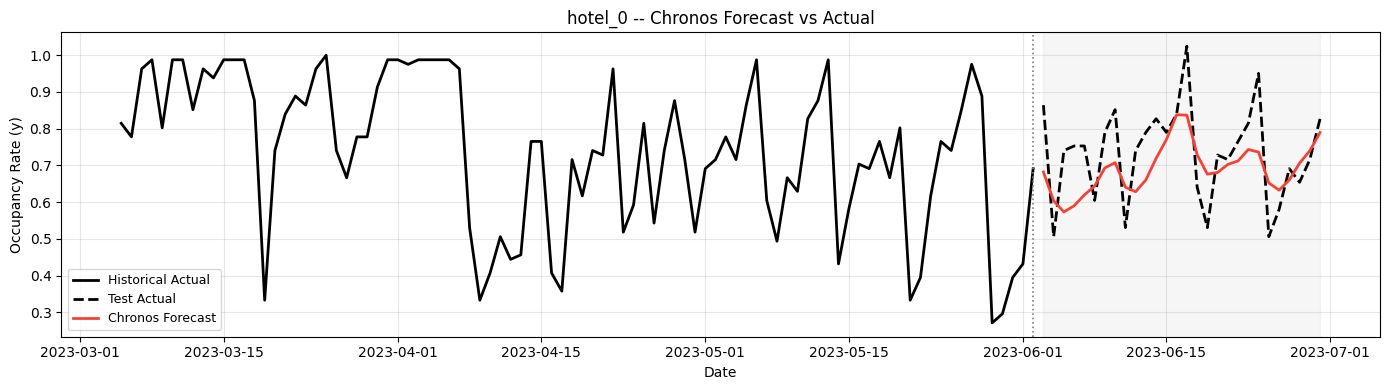

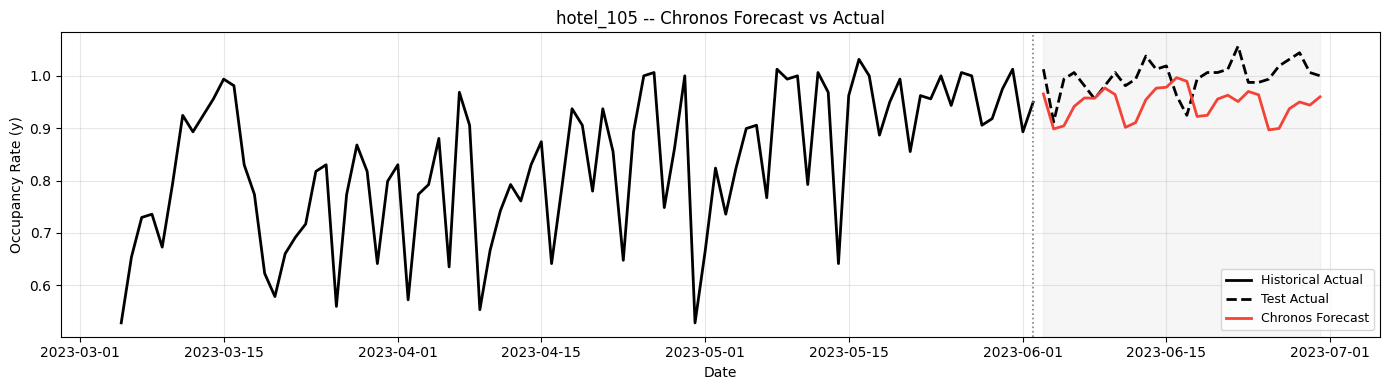

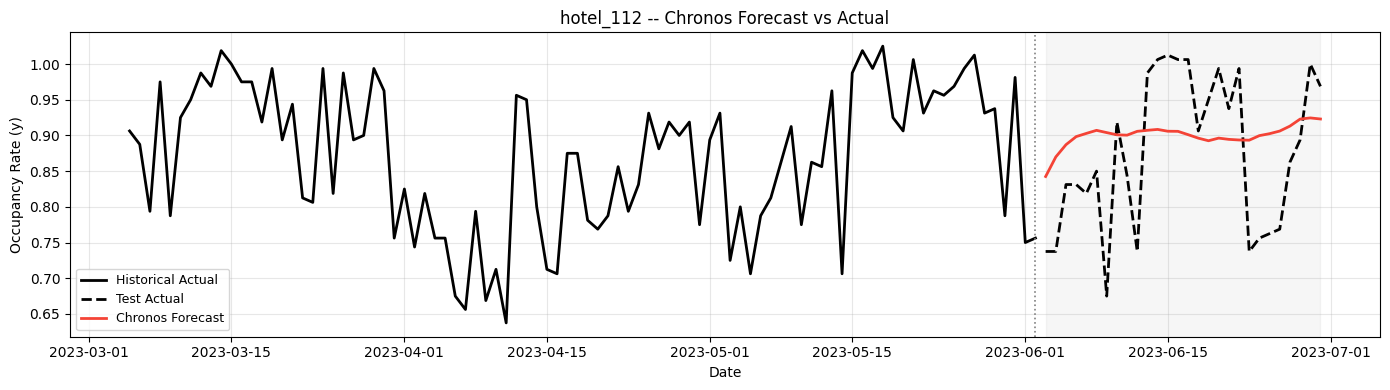

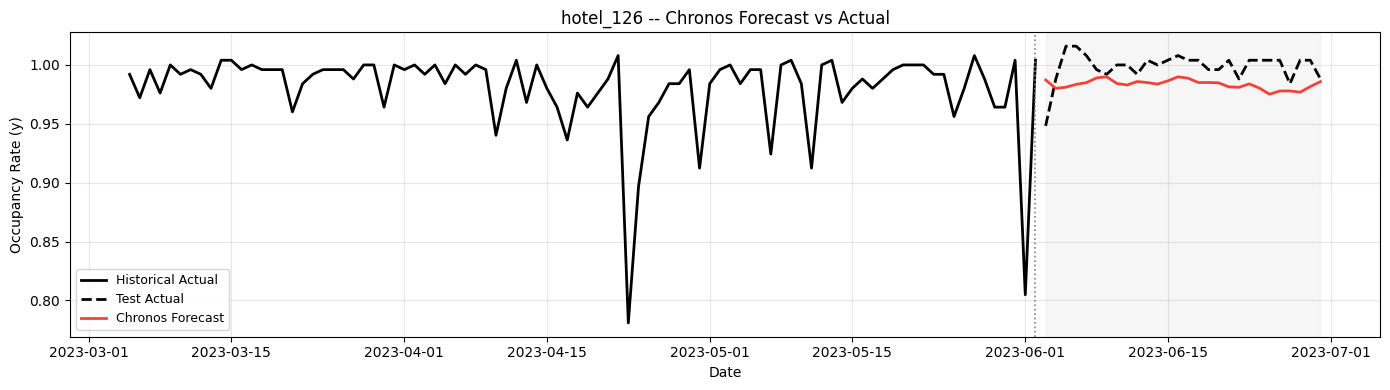

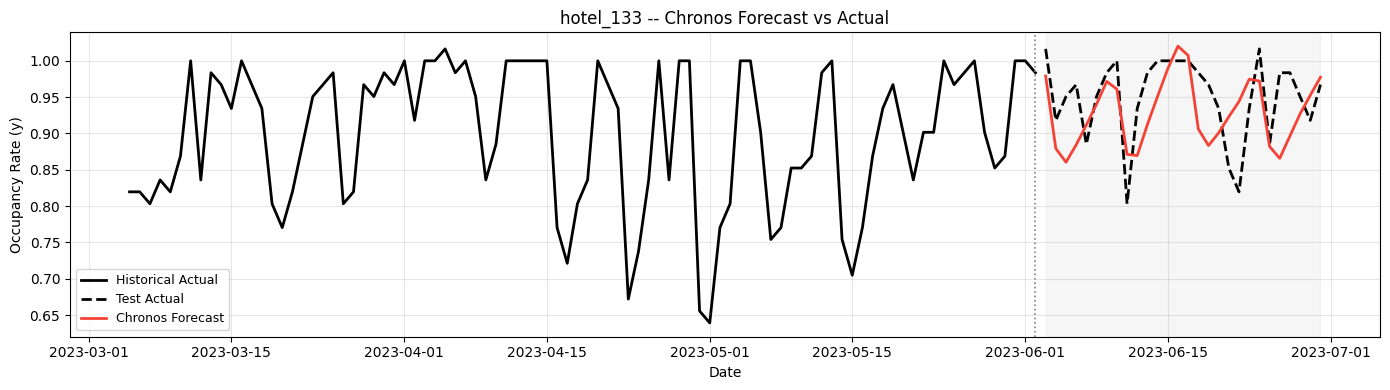

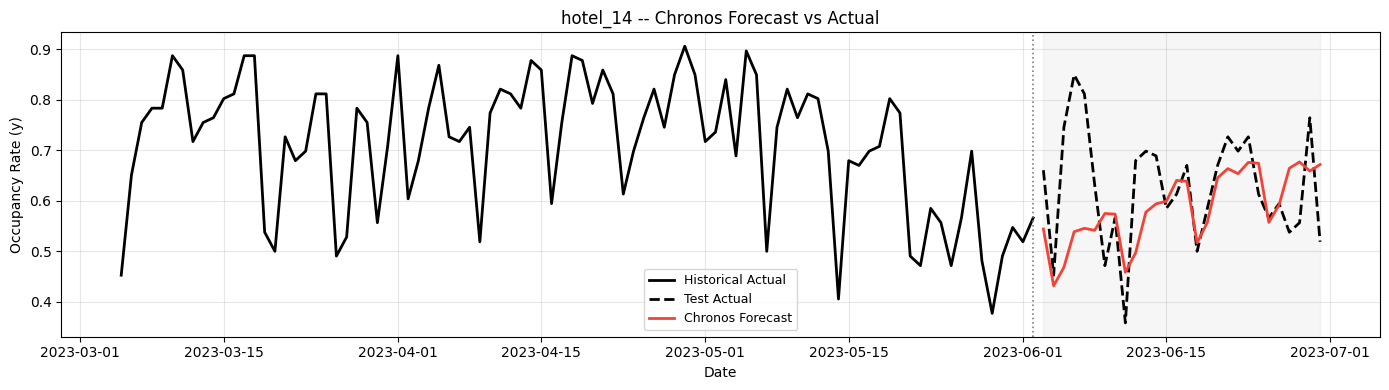

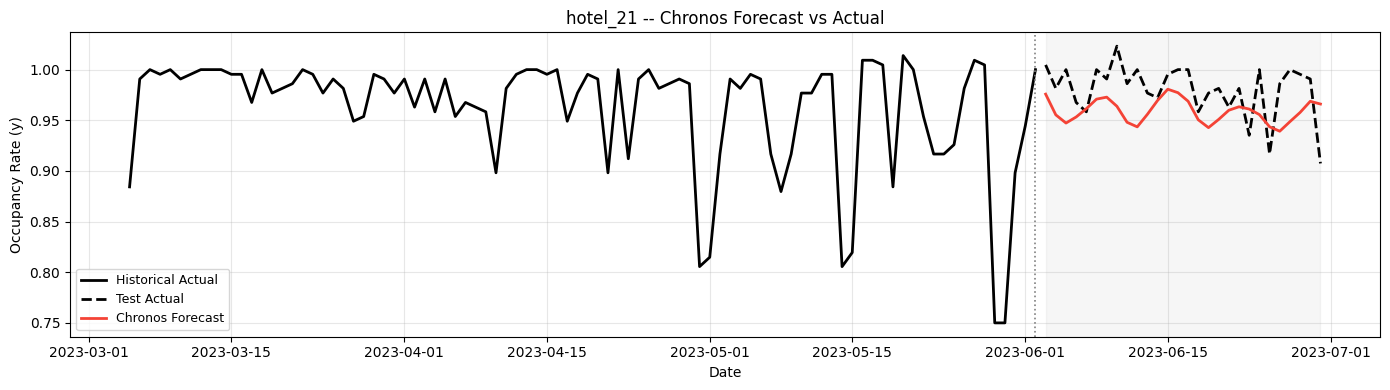

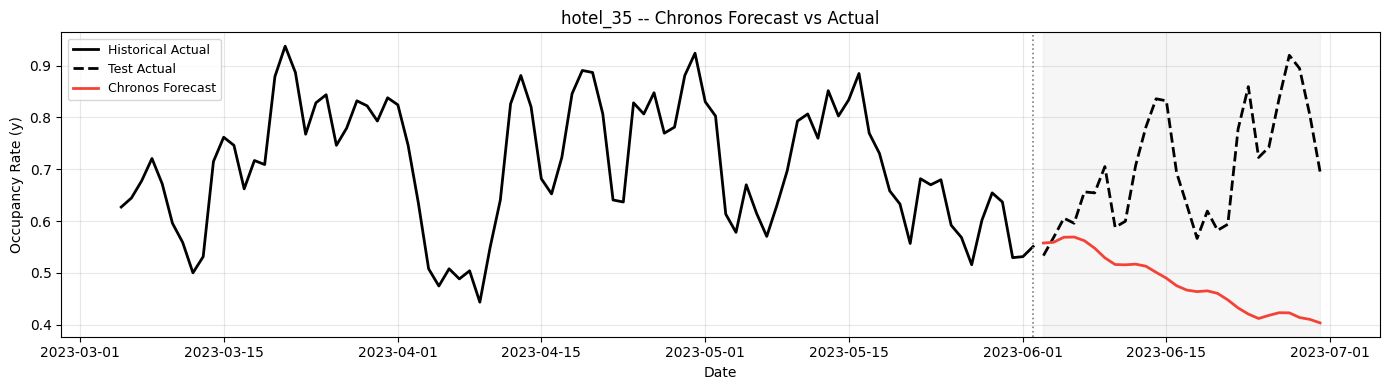

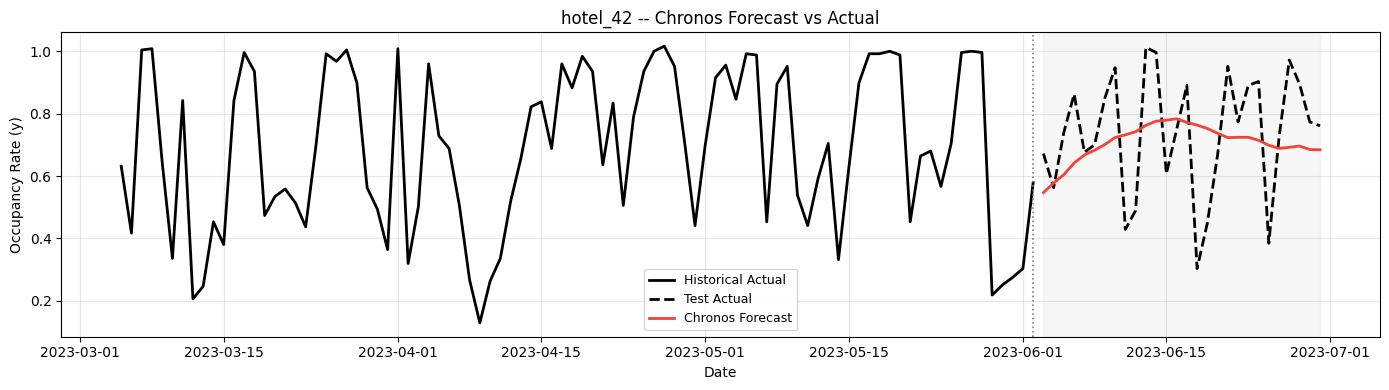

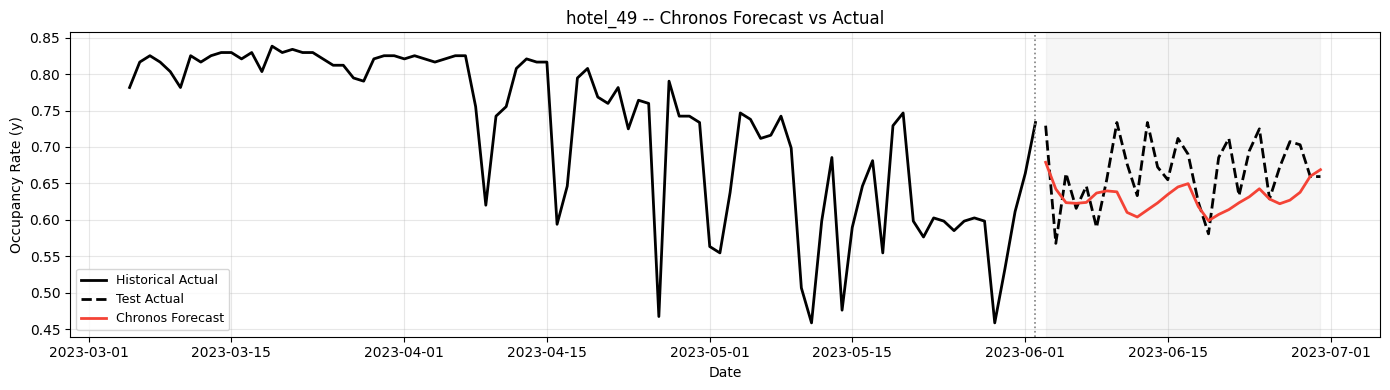

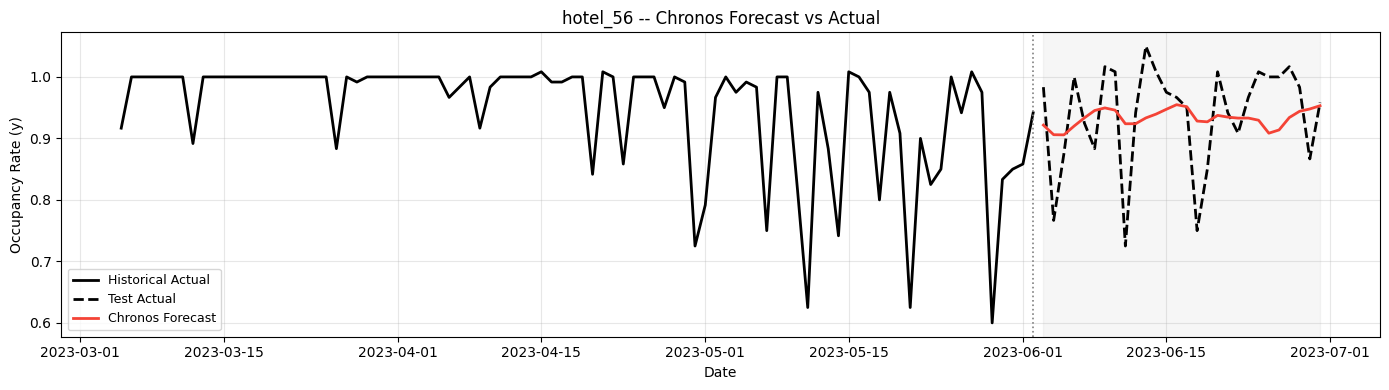

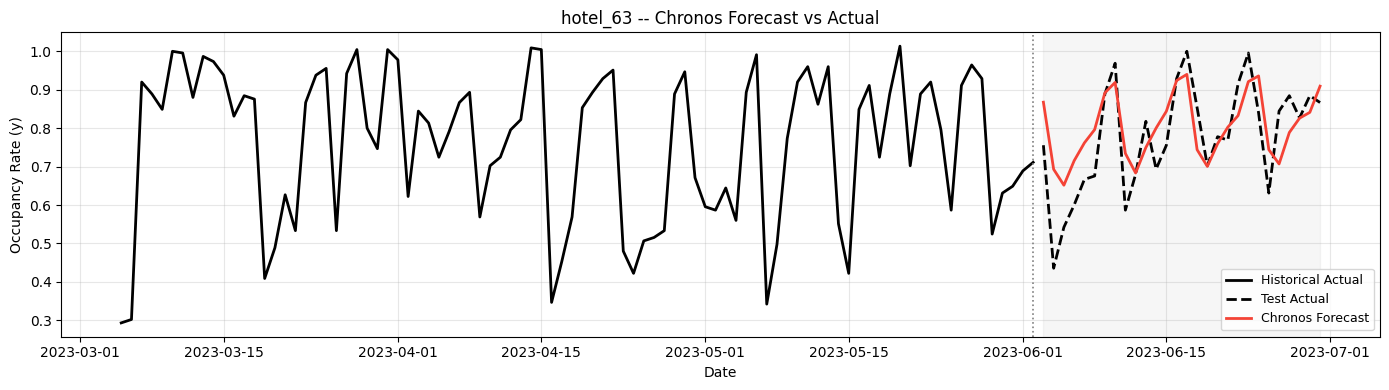

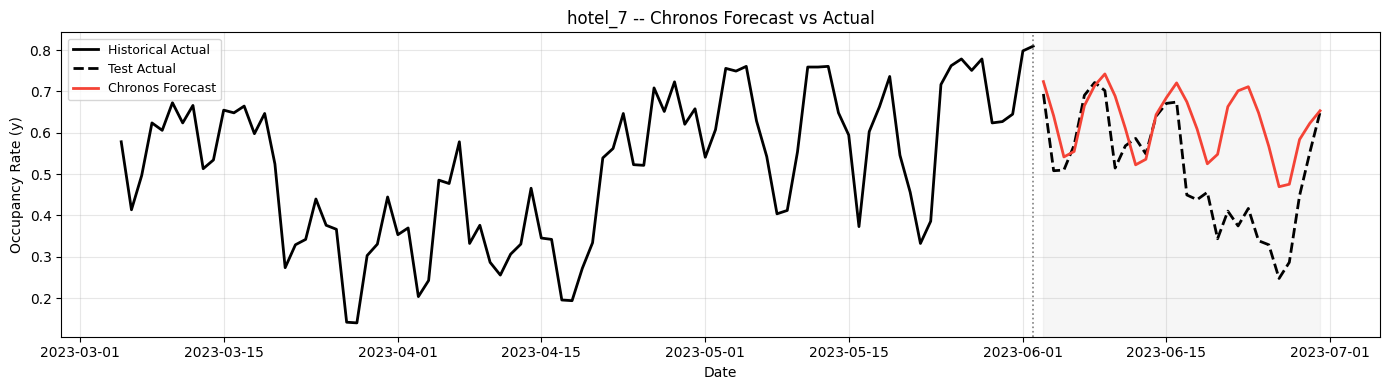

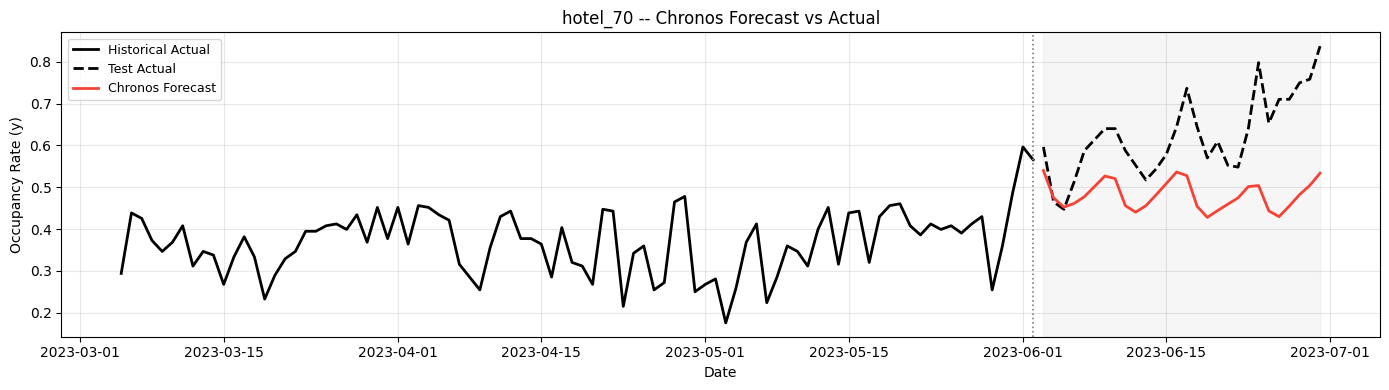

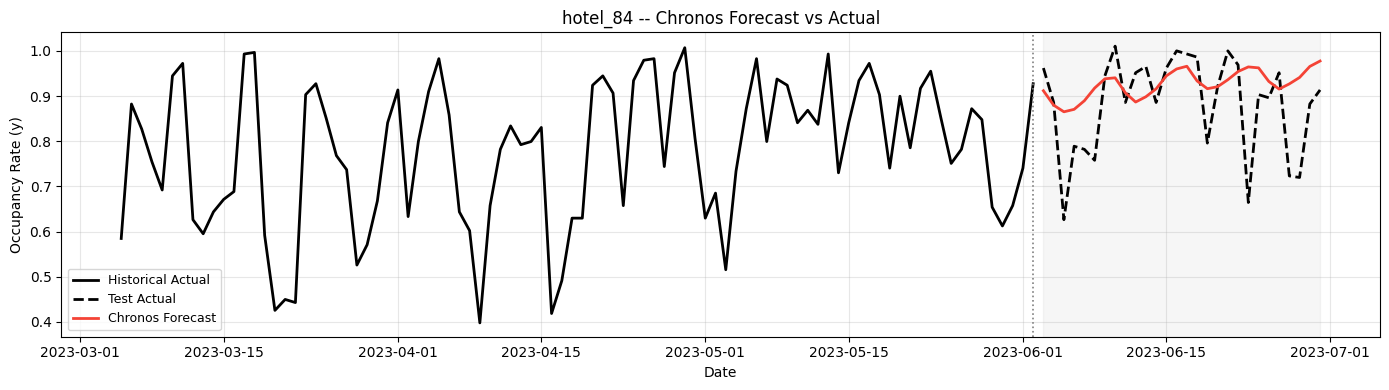

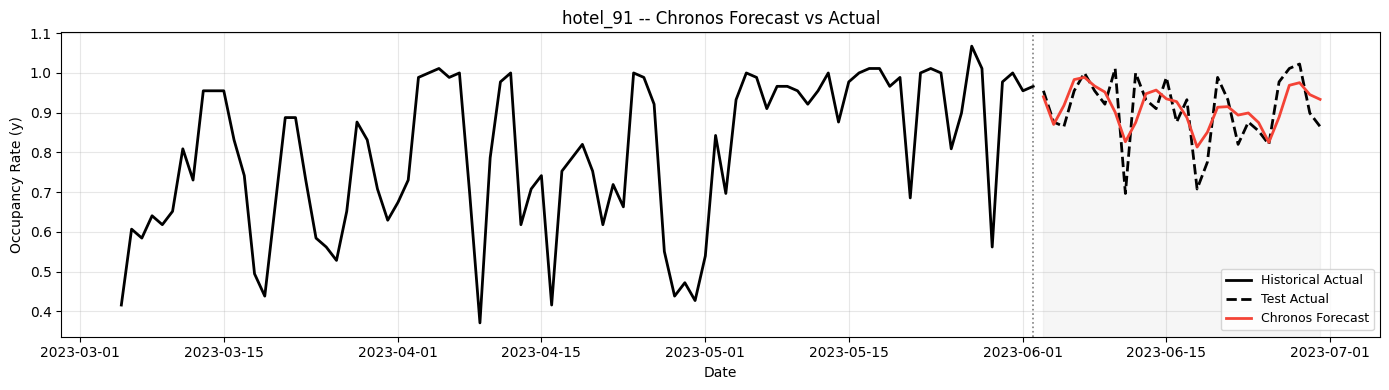

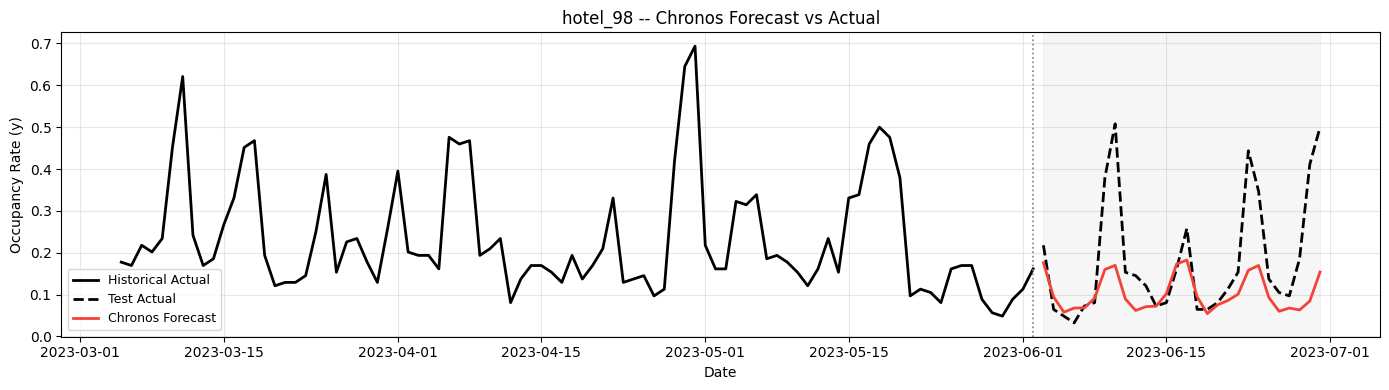

17 Chronos plots saved to outputs/plots/


In [34]:
import matplotlib.pyplot as plt
import os

os.makedirs("outputs/plots", exist_ok=True)

last_cutoff = t_cv['cutoff'].max()
cv_plot     = t_cv[t_cv['cutoff'] == last_cutoff].copy()
hotels      = sorted(df['unique_id'].unique())

for hotel in hotels:
    history     = df[(df['unique_id'] == hotel) & (df['ds'] <= last_cutoff)].tail(90)
    test_window = cv_plot[cv_plot['unique_id'] == hotel].copy()

    if test_window.empty:
        print(f"No CV data for {hotel} -- skipping")
        continue

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(history['ds'], history['y'], color='black', linewidth=2.0, label='Historical Actual')
    ax.plot(test_window['ds'], test_window['y'], color='black', linewidth=2.0, linestyle='--', label='Test Actual')
    ax.plot(test_window['ds'], test_window['Chronos'], color='#F44336', linewidth=2.0, label='Chronos Forecast')

    ax.axvspan(test_window['ds'].min(), test_window['ds'].max(), alpha=0.07, color='gray')
    ax.axvline(last_cutoff, color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(f'{hotel} -- Chronos Forecast vs Actual', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Occupancy Rate (y)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(f"outputs/plots/{hotel}_chronos_forecast_vs_actual.png", dpi=120, bbox_inches='tight')
    plt.show()

print(f"{len(hotels)} Chronos plots saved to outputs/plots/")

# TabPFN Machine Learning Completed in Colab

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=3282df18-99b5-499a-b7a7-ae4fbc8828b9' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>